# ProtVL Quickstart

**ProtVL** predicts protein localization images from reference microscopy channels
(nucleus, ER, microtubules) using a conditional diffusion model.

**Workflow:**
1. Download pre-trained checkpoints (first time only)
2. Load a reference cell image
3. Explore available proteins and cell lines
4. Predict protein localization
5. Visualize and save results

## Setup

In [2]:
import numpy as np
from tifffile import imread

from protvl import ProtVL

c:\Users\57539\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Download Checkpoints

Downloads model weights into the `protvl/` package directory.
Skip this cell if you have already downloaded them.

In [3]:
ProtVL.download_checkpoints()

Checkpoint already exists at D:\ProtVL\protvl\checkpoint
VAE already exists at D:\ProtVL\protvl\vae
Ready: {'checkpoint_dir': 'D:\\ProtVL\\protvl\\checkpoint', 'vae_dir': 'D:\\ProtVL\\protvl\\vae'}


{'checkpoint_dir': 'D:\\ProtVL\\protvl\\checkpoint',
 'vae_dir': 'D:\\ProtVL\\protvl\\vae'}

## Step 2: Initialize Model

In [4]:
model = ProtVL()
print(model.summary())

ProtVL Model Summary
  Parameters:    463,020,096
  Proteins:      12,809
  Cell lines:    41
  Device:        cuda
  Dtype:         torch.float32
  Checkpoint:    D:\ProtVL\protvl\checkpoint


## Step 3: Explore Available Proteins and Cell Lines

Check what proteins and cell lines the model supports before predicting.

In [5]:
print(f"Proteins available: {len(model.available_proteins)}")
print("First 10:", model.available_proteins[:10])

print(f"\nCell lines available: {len(model.available_cell_lines)}")
print(model.available_cell_lines)

Proteins available: 12809
First 10: ['A1CF', 'A4GALT', 'AAAS', 'AACS', 'AADAT', 'AAGAB', 'AAK1', 'AAMDC', 'AAMP', 'AANAT']

Cell lines available: 41
['A-431', 'A-549', 'AF22', 'ASC52telo', 'BJ [Human fibroblast]', 'CACO-2', 'EFO-21', 'GAMG', 'HAP1', 'HBEC3-KT', 'HDLM-2', 'HEK293', 'HEL', 'HUVEC TERT2', 'HaCaT', 'HeLa', 'Hep-G2', 'JURKAT', 'K-562', 'LHCN-M2', 'MCF-7', 'NB4', 'OE19', 'PC-3', 'PODO SVTERT152', 'PODO TERT256', 'REH', 'RPTEC TERT1', 'RT-4', 'Rh30', 'SH-SY5Y', 'SK-MEL-30', 'SiHa', 'Sperm', 'SuSa', 'THP-1', 'U-251MG', 'U2OS', 'hTCEpi', 'hTERT-RPE1', 'hTERT-RPE1 (serum starved)']


## Step 4: Load a Reference Image

The model expects a reference cell image with shape `[H, W, 3]` or `[H, W, 4]`,
pixel values in `[0, 1]` or `[0, 255]`.
For 4-channel TIFFs, channels 0, 2, and 3 are used as conditioning
(nucleus, ER, microtubules); channel 1 is ignored.

In [6]:
# Replace with the path to your reference image
REF_PATH = "example_cell_reference_input/cell_0.tiff"

ref_image = imread(REF_PATH)
print(f"Image shape: {ref_image.shape}, dtype: {ref_image.dtype}")

Image shape: (512, 512, 3), dtype: float32


## Step 5: Predict Protein Localization

Pass one or more `(image, protein, cell_line)` combinations in a single call.
Each entry in the lists corresponds to one prediction.

In [8]:
results = model.predict(
    images=[ref_image, ref_image],
    protein_names=["TOMM20", "BRD4"],
    cell_line_names=["A-431", "A-431"],
    num_inference_steps=50,   # lower (e.g. 20) for faster, less accurate results
    seed=42,                  # set for reproducibility
)

print(f"Predicted {len(results)} image(s)")
print(f"Output shape per image: {results[0].shape}")

c:\Users\57539\AppData\Local\Programs\Python\Python311\Lib\site-packages\diffusers\models\attention_processor.py:3313: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  hidden_states = F.scaled_dot_product_attention(


Predicted 2 image(s)
Output shape per image: (512, 512)


## Step 6: Visualize Results

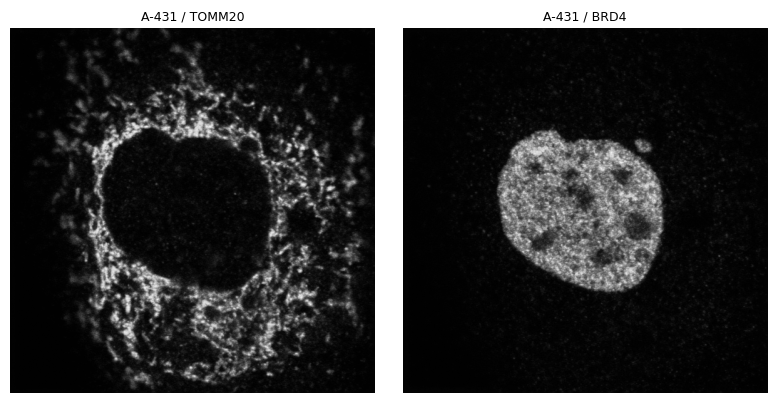

In [9]:
results.show_prediction()

## Step 7: Save Results

Predictions are saved as uint8 TIFFs named
`{prefix}_{index}_{cell_line}_cell_{protein}.tif`.

In [10]:
results.save_prediction(
    prefix="quickstart",
    directory="predictions/",
)
print("Saved to predictions/")

Saved to predictions/


## Next Steps

**Predict many proteins at once** — pass lists of any length to `model.predict()`;
use `batch_size` to control GPU memory usage:
```python
results = model.predict(
    images=[ref] * len(proteins),
    protein_names=proteins,
    cell_line_names=["U-2 OS"] * len(proteins),
    batch_size=8,
)
```

**Fine-tune on your own data** — provide a directory of 4-channel TIFFs:
```python
model.fit(
    image_dir="data/train",
    image_files=["cell_0.tiff", "cell_1.tiff"],
    protein_names=["CDT1", "TUBB"],
    cell_line_names=["U-2 OS", "U-2 OS"],
    output_dir="finetuned/",
    num_epochs=50,
)
```

**Save and reload a fine-tuned model:**
```python
model.save("finetuned/")
model = ProtVL(checkpoint_dir="finetuned/")
```